# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
plt.style.use("seaborn-v0_8-darkgrid")

print("✅ Libraries loaded!")

✅ Libraries loaded!


# Load news data

In [2]:
# Load financial news dataset
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")

print("=== 📰 NEWS DATASET ===")
print(f"✅ Shape: {news_df.shape}")
print(f"✅ Rows: {news_df.shape[0]:,}")
print(f"✅ Columns: {news_df.columns.tolist()}")
print(f"\n🔍 Sample data:")
news_df.head()

=== 📰 NEWS DATASET ===
✅ Shape: (1407328, 6)
✅ Rows: 1,407,328
✅ Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

🔍 Sample data:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/stocks-that-hit-52-week-highs-on-friday,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/stocks-that-hit-52-week-highs-on-wednesday,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/71-biggest-movers-from-friday,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/46-stocks-moving-in-fridays-mid-day-session,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,"B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88",https://www.benzinga.com/news/20/05/16095304/b-of-a-securities-maintains-neutral-on-agilent-tech...,Vick Meyer,2020-05-22 11:38:59-04:00,A


# Load all stock data

In [3]:
# Load all 6 stock datasets
stocks = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA"]
stock_data = {}

for stock in stocks:
    df = pd.read_csv(f"../data/{stock}.csv")
    stock_data[stock] = df
    print(f"✅ {stock}: {df.shape[0]:,} rows | Columns: {df.columns.tolist()}")

print(f"\n🎉 Total stocks loaded: {len(stock_data)}")

✅ AAPL: 3,774 rows | Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
✅ AMZN: 3,774 rows | Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
✅ GOOG: 3,774 rows | Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
✅ META: 2,923 rows | Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
✅ MSFT: 3,774 rows | Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
✅ NVDA: 3,774 rows | Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

🎉 Total stocks loaded: 6


# Quick news data overview

In [4]:
print("=== 📰 NEWS DATA OVERVIEW ===\n")

# Basic info
print(f"Total articles: {len(news_df):,}")
print(f"\nColumn types:")
print(news_df.dtypes)

print(f"\nMissing values:")
print(news_df.isna().sum())

print(f"\nSample headlines:")
for i, headline in enumerate(news_df["headline"].head(5)):
    print(f"  {i+1}. {headline}")

=== 📰 NEWS DATA OVERVIEW ===

Total articles: 1,407,328

Column types:
Unnamed: 0    int64
headline        str
url             str
publisher       str
date            str
stock           str
dtype: object

Missing values:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

Sample headlines:
  1. Stocks That Hit 52-Week Highs On Friday
  2. Stocks That Hit 52-Week Highs On Wednesday
  3. 71 Biggest Movers From Friday
  4. 46 Stocks Moving In Friday's Mid-Day Session
  5. B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88


# Quick stock data overview

In [5]:
print("=== 📈 STOCK DATA OVERVIEW ===\n")

for stock, df in stock_data.items():
    print(f"📊 {stock}")
    print(f"   Date range: {df.iloc[0,0]} to {df.iloc[-1,0]}")
    print(f"   Rows: {len(df):,}")
    print(f"   Columns: {df.columns.tolist()}")
    print()

=== 📈 STOCK DATA OVERVIEW ===

📊 AAPL
   Date range: 2009-01-02 to 2023-12-29
   Rows: 3,774
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

📊 AMZN
   Date range: 2009-01-02 to 2023-12-29
   Rows: 3,774
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

📊 GOOG
   Date range: 2009-01-02 to 2023-12-29
   Rows: 3,774
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

📊 META
   Date range: 2012-05-18 to 2023-12-29
   Rows: 2,923
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

📊 MSFT
   Date range: 2009-01-02 to 2023-12-29
   Rows: 3,774
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

📊 NVDA
   Date range: 2009-01-02 to 2023-12-29
   Rows: 3,774
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']



# Clean and filter data

In [6]:
# Drop unnecessary column
news_df = news_df.drop(columns=["Unnamed: 0"])

# Filter only our 6 stocks
our_stocks = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA"]
filtered_news = news_df[news_df["stock"].isin(our_stocks)].copy()

print("=== 📰 FILTERED NEWS DATA ===")
print(f"✅ Total articles (all stocks): {len(news_df):,}")
print(f"✅ Articles for our 6 stocks: {len(filtered_news):,}")
print(f"\n📊 Articles per stock:")
print(filtered_news["stock"].value_counts())

=== 📰 FILTERED NEWS DATA ===
✅ Total articles (all stocks): 1,407,328
✅ Articles for our 6 stocks: 5,064

📊 Articles per stock:
stock
NVDA    3146
GOOG    1199
AAPL     441
AMZN     278
Name: count, dtype: int64


# Understand the date column

In [8]:
# Parse dates with mixed format
filtered_news["date"] = pd.to_datetime(
    filtered_news["date"], 
    format="mixed",
    utc=True
)

# Extract useful date features
filtered_news["year"]        = filtered_news["date"].dt.year
filtered_news["month"]       = filtered_news["date"].dt.month
filtered_news["day"]         = filtered_news["date"].dt.day
filtered_news["hour"]        = filtered_news["date"].dt.hour
filtered_news["day_of_week"] = filtered_news["date"].dt.day_name()

print("=== 📅 DATE ANALYSIS ===")
print(f"Earliest article: {filtered_news['date'].min()}")
print(f"Latest article:   {filtered_news['date'].max()}")
print(f"Date range: {(filtered_news['date'].max() - filtered_news['date'].min()).days} days")
print(f"\nArticles by year:")
print(filtered_news["year"].value_counts().sort_index())

=== 📅 DATE ANALYSIS ===
Earliest article: 2011-03-03 00:00:00+00:00
Latest article:   2020-06-10 19:25:13+00:00
Date range: 3387 days

Articles by year:
year
2011     226
2012     183
2013     144
2014     118
2015     180
2016     337
2017     615
2018     573
2019    1221
2020    1467
Name: count, dtype: int64


# Headline length analysis

In [9]:
# Analyze headline lengths
filtered_news["headline_length"] = filtered_news["headline"].str.len()
filtered_news["word_count"]      = filtered_news["headline"].str.split().str.len()

print("=== 📝 HEADLINE STATISTICS ===")
print(f"\nHeadline character length:")
print(filtered_news["headline_length"].describe().round(2))
print(f"\nWord count per headline:")
print(filtered_news["word_count"].describe().round(2))

# Longest and shortest headlines
print(f"\n🏆 Longest headline:")
print(f"  {filtered_news.loc[filtered_news['headline_length'].idxmax(), 'headline']}")
print(f"\n🔤 Shortest headline:")
print(f"  {filtered_news.loc[filtered_news['headline_length'].idxmin(), 'headline']}")

=== 📝 HEADLINE STATISTICS ===

Headline character length:
count    5064.00
mean       80.28
std        47.36
min        16.00
25%        51.00
50%        69.00
75%        88.00
max       382.00
Name: headline_length, dtype: float64

Word count per headline:
count    5064.00
mean       12.65
std         7.32
min         2.00
25%         8.00
50%        11.00
75%        14.00
max        65.00
Name: word_count, dtype: float64

🏆 Longest headline:
  Shares of several semiconductor companies are trading lower as optimism around the upcoming U.S.-China trade talks waned. A report says China is toning down its expectations of the meeting. The U.S. expanded its trade blacklist, and scheduled an increase in tariffs on $250 billion worth of Chinese goods from 25% to 30% on Oct. 15, which will go into effect if no progress is made.

🔤 Shortest headline:
  A BUZ-Worthy ETF


# Check META and MSFT symbols

In [10]:
# Check what symbols are used for META and MSFT
print("=== 🔍 CHECKING STOCK SYMBOLS ===\n")

# Search for Facebook/Meta related symbols
fb_check = news_df[news_df["stock"].isin(["FB", "META", "FBOOK"])]
print(f"Facebook/Meta articles:")
print(fb_check["stock"].value_counts())

# Search for Microsoft
msft_check = news_df[news_df["stock"].isin(["MSFT", "MICROSOFT"])]
print(f"\nMicrosoft articles:")
print(msft_check["stock"].value_counts())

# Show all unique symbols
print(f"\nTotal unique stock symbols: {news_df['stock'].nunique():,}")
print(f"\nTop 20 most covered stocks:")
print(news_df["stock"].value_counts().head(20))

=== 🔍 CHECKING STOCK SYMBOLS ===

Facebook/Meta articles:
stock
FB    380
Name: count, dtype: int64

Microsoft articles:
Series([], Name: count, dtype: int64)

Total unique stock symbols: 6,204

Top 20 most covered stocks:
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
QCOM    2941
JNJ     2928
DAL     2926
BABA    2858
KO      2797
AA      2739
EWU     2702
ORCL    2701
FDX     2629
HD      2612
Name: count, dtype: int64


# Fix and expand our filter

In [11]:
# Update our stock filter to include FB for META
our_stocks_expanded = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA", "FB"]

filtered_news = news_df[news_df["stock"].isin(our_stocks_expanded)].copy()

# Map FB to META
filtered_news["stock"] = filtered_news["stock"].replace("FB", "META")

# Re-parse dates
filtered_news["date"] = pd.to_datetime(
    filtered_news["date"], format="mixed", utc=True
)

# Re-extract date features
filtered_news["year"]        = filtered_news["date"].dt.year
filtered_news["month"]       = filtered_news["date"].dt.month
filtered_news["day"]         = filtered_news["date"].dt.day
filtered_news["hour"]        = filtered_news["date"].dt.hour
filtered_news["day_of_week"] = filtered_news["date"].dt.day_name()
filtered_news["date_only"]   = filtered_news["date"].dt.date

print("=== 📰 UPDATED FILTERED NEWS ===")
print(f"✅ Total articles: {len(filtered_news):,}")
print(f"\n📊 Articles per stock:")
print(filtered_news["stock"].value_counts())

=== 📰 UPDATED FILTERED NEWS ===
✅ Total articles: 5,444

📊 Articles per stock:
stock
NVDA    3146
GOOG    1199
AAPL     441
META     380
AMZN     278
Name: count, dtype: int64


# Articles per stock chart

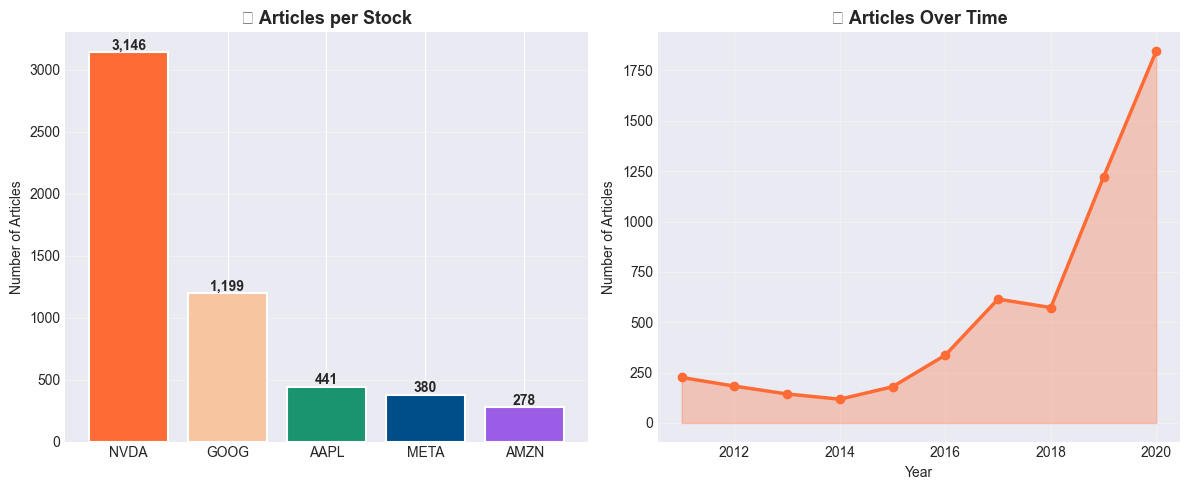

✅ Chart saved!


In [12]:
plt.figure(figsize=(12, 5))

# Plot 1 — Articles per stock
plt.subplot(1, 2, 1)
stock_counts = filtered_news["stock"].value_counts()
colors = ["#FF6B35", "#F7C59F", "#1A936F", "#004E89", "#9B5DE5"]
bars = plt.bar(stock_counts.index, stock_counts.values, 
               color=colors, edgecolor="white", linewidth=1.5)
plt.title("📰 Articles per Stock", fontweight="bold", fontsize=13)
plt.ylabel("Number of Articles")
plt.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, stock_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{val:,}", ha="center", fontweight="bold", fontsize=10)

# Plot 2 — Articles by year
plt.subplot(1, 2, 2)
yearly = filtered_news["year"].value_counts().sort_index()
plt.plot(yearly.index, yearly.values, 
         color="#FF6B35", linewidth=2.5, marker="o", markersize=6)
plt.fill_between(yearly.index, yearly.values, alpha=0.3, color="#FF6B35")
plt.title("📅 Articles Over Time", fontweight="bold", fontsize=13)
plt.ylabel("Number of Articles")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/articles_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

# Publisher analysis

=== 📰 PUBLISHER ANALYSIS ===

Top 15 publishers:
publisher
Benzinga Newsdesk    1040
Lisa Levin            477
Paul Quintaro         293
Charles Gross         272
JJ Kinahan            246
Wayne Duggan          235
Benzinga_Newsdesk     208
Jayson Derrick        203
Neer Varshney         194
Shanthi Rexaline      159
Vick Meyer            140
Monica Gerson         126
Craig Jones           120
ETF Professor         101
Shivdeep Dhaliwal      91
Name: count, dtype: int64


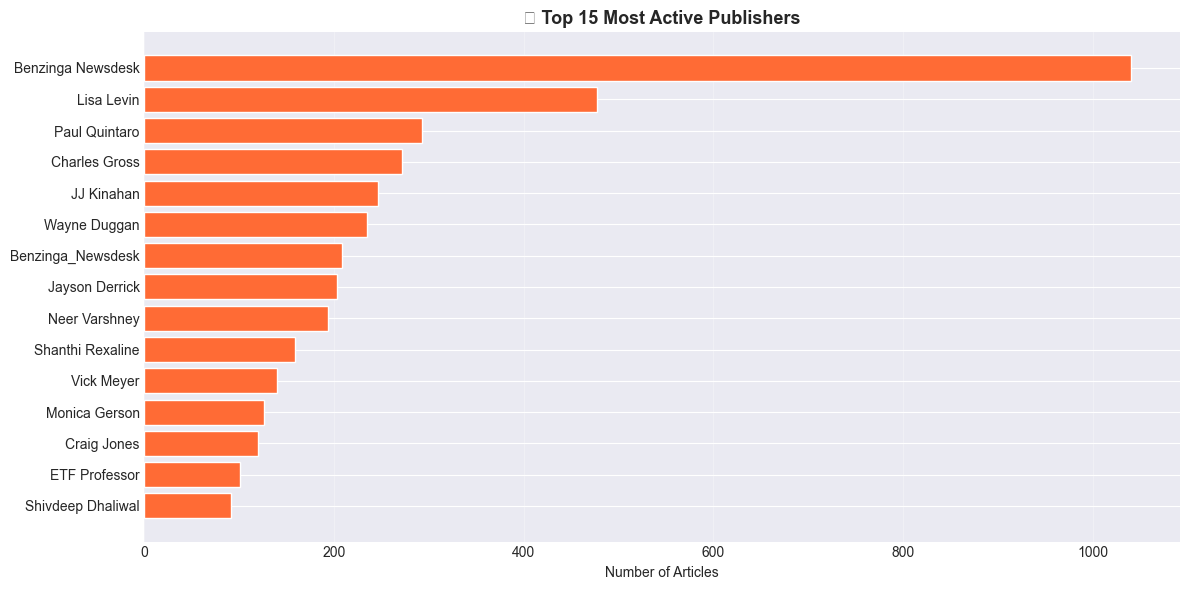

✅ Publisher chart saved!


In [13]:
print("=== 📰 PUBLISHER ANALYSIS ===\n")

# Top publishers
top_publishers = filtered_news["publisher"].value_counts().head(15)
print("Top 15 publishers:")
print(top_publishers)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_publishers.index[::-1], 
                top_publishers.values[::-1],
                color="#FF6B35", edgecolor="white")
plt.title("🏆 Top 15 Most Active Publishers", fontweight="bold", fontsize=13)
plt.xlabel("Number of Articles")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../data/publishers.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Publisher chart saved!")

# Publishing time analysis

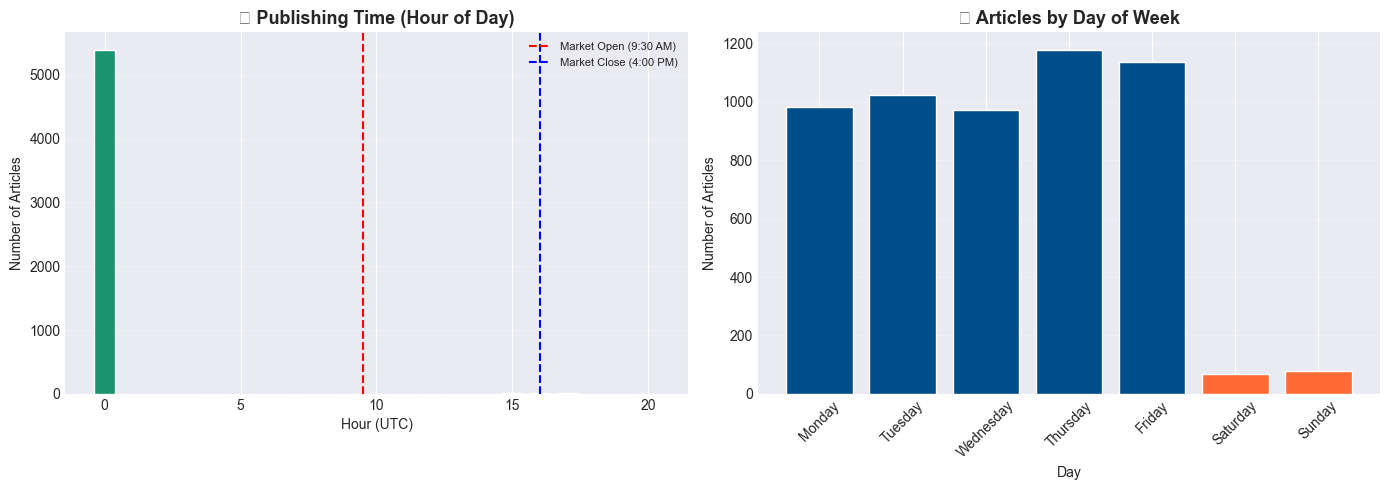

✅ Time analysis chart saved!


In [14]:
plt.figure(figsize=(14, 5))

# Plot 1 — Articles by hour
plt.subplot(1, 2, 1)
hourly = filtered_news["hour"].value_counts().sort_index()
plt.bar(hourly.index, hourly.values, color="#1A936F", edgecolor="white")
plt.title("⏰ Publishing Time (Hour of Day)", fontweight="bold", fontsize=13)
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Articles")
plt.axvline(x=9.5, color="red", linestyle="--", 
            label="Market Open (9:30 AM)")
plt.axvline(x=16, color="blue", linestyle="--", 
            label="Market Close (4:00 PM)")
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)

# Plot 2 — Articles by day of week
plt.subplot(1, 2, 2)
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", 
              "Friday", "Saturday", "Sunday"]
daily = filtered_news["day_of_week"].value_counts()
daily = daily.reindex(days_order, fill_value=0)
colors_day = ["#FF6B35" if d in ["Saturday", "Sunday"] 
              else "#004E89" for d in days_order]
plt.bar(daily.index, daily.values, color=colors_day, edgecolor="white")
plt.title("📆 Articles by Day of Week", fontweight="bold", fontsize=13)
plt.xlabel("Day")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../data/publishing_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Time analysis chart saved!")

# Clean headlines and find keywords

In [15]:
from collections import Counter
import re

# Words to ignore - they add no meaning
STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to",
    "for", "of", "with", "by", "from", "is", "are", "was", "were",
    "be", "been", "being", "have", "has", "had", "do", "does", "did",
    "will", "would", "could", "should", "may", "might", "shall",
    "its", "it", "this", "that", "these", "those", "as", "up", "s",
    "than", "into", "after", "over", "about", "than", "more", "also",
    "their", "our", "your", "his", "her", "we", "he", "she", "they"
}

def clean_headline(text):
    """Clean and tokenize headline"""
    # Lowercase
    text = text.lower()
    # Remove special characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Split into words
    words = text.split()
    # Remove stopwords and short words
    words = [w for w in words if w not in STOPWORDS and len(w) > 2]
    return words

# Apply cleaning
filtered_news["words"] = filtered_news["headline"].apply(clean_headline)

# Count all words
all_words = []
for words in filtered_news["words"]:
    all_words.extend(words)

word_counts = Counter(all_words)

print("=== 🔤 TOP 30 MOST COMMON WORDS ===\n")
for word, count in word_counts.most_common(30):
    bar = "█" * (count // 10)
    print(f"{word:<20} {count:>5} {bar}")

=== 🔤 TOP 30 MOST COMMON WORDS ===

nvidia                1597 ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
shares                 575 █████████████████████████████████████████████████████████
stocks                 574 █████████████████████████████████████████████████████████
google                 498 █████████████████████████████████████████████████
market                 473 ███████████████████████████████████████████████
earnings               447 ████████████████████████████████████████████
target                 431 ███████████████████████████████████████████
apple                  421 ██████████████████████████████████████████
price                  390 ███████████████████████████████████████
says                   337 █████████████████████████████████
trading                325 ████████████████████████████████
maintains              300 ███████████████████████████

# WordCloud visualization

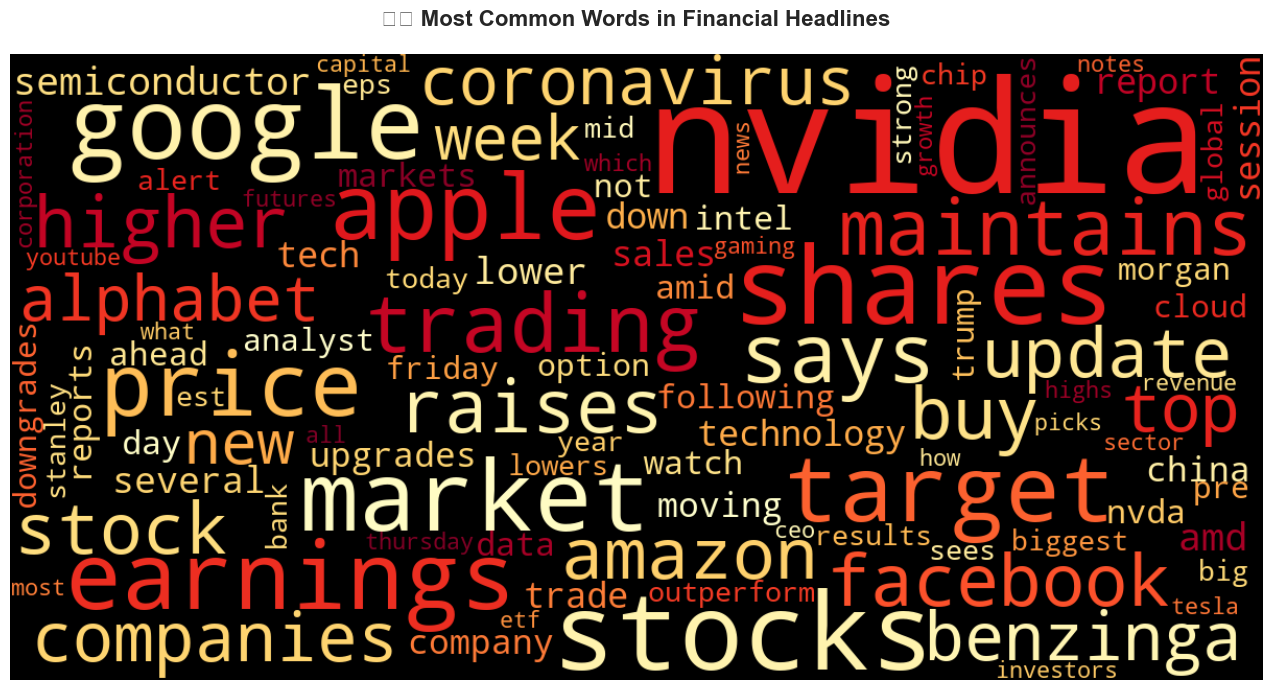

✅ WordCloud saved!


In [18]:
from wordcloud import WordCloud

# Create WordCloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="black",
    colormap="YlOrRd",
    max_words=100,
    min_font_size=10,
    max_font_size=150,
    random_state=42
).generate_from_frequencies(word_counts)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("☁️ Most Common Words in Financial Headlines",
          fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("../data/wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ WordCloud saved!")

# Keywords by stock

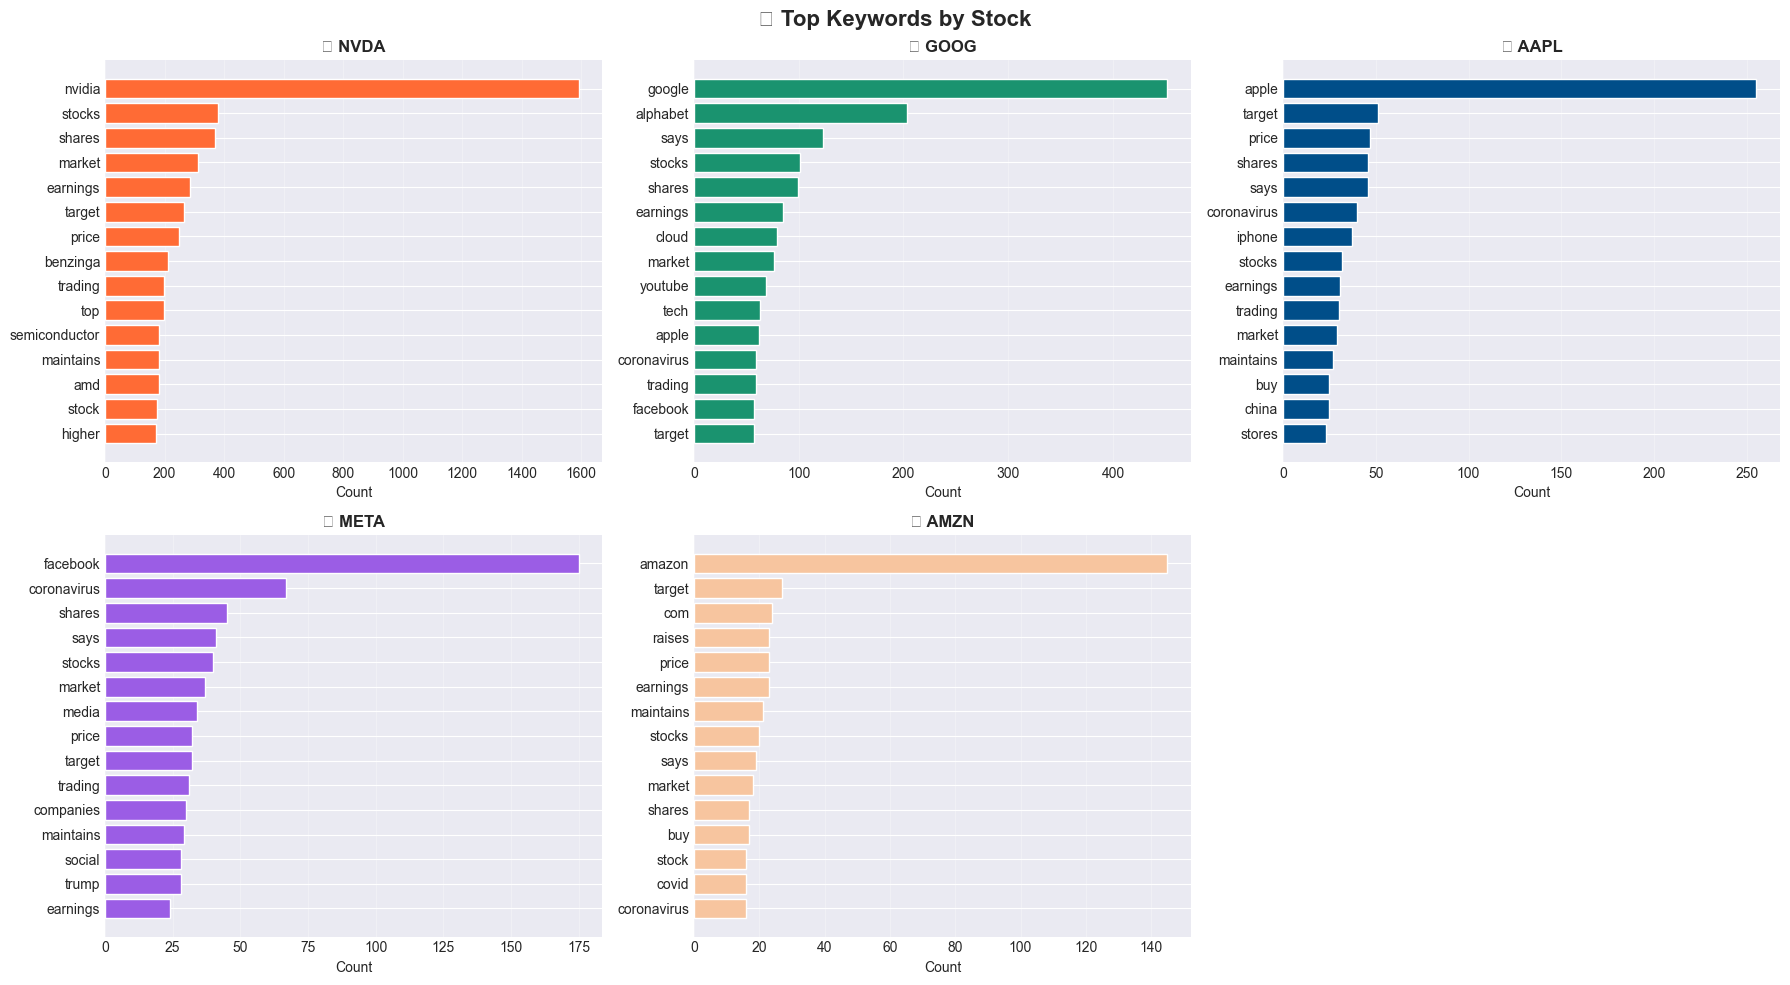

✅ Keywords by stock chart saved!


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("🔤 Top Keywords by Stock", fontsize=16, fontweight="bold")

stocks_to_plot = ["NVDA", "GOOG", "AAPL", "META", "AMZN"]
axes_flat = axes.flatten()

colors = ["#FF6B35", "#1A936F", "#004E89", "#9B5DE5", "#F7C59F"]

for idx, stock in enumerate(stocks_to_plot):
    ax = axes_flat[idx]

    # Get words for this stock
    stock_words = []
    for words in filtered_news[filtered_news["stock"] == stock]["words"]:
        stock_words.extend(words)

    # Count and get top 15
    stock_counts = Counter(stock_words).most_common(15)
    words_list  = [w[0] for w in stock_counts][::-1]
    counts_list = [w[1] for w in stock_counts][::-1]

    ax.barh(words_list, counts_list, color=colors[idx], edgecolor="white")
    ax.set_title(f"📊 {stock}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Count")
    ax.grid(axis="x", alpha=0.3)

# Hide last empty subplot
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig("../data/keywords_by_stock.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Keywords by stock chart saved!")

# Financial event keywords

=== 📰 FINANCIAL EVENT ANALYSIS ===

Price Target        :   363 articles (6.7%)
Earnings            :   614 articles (11.3%)
Rating              :   726 articles (13.3%)
FDA/Drug            :    15 articles (0.3%)
Partnership         :   153 articles (2.8%)
CEO/Executive       :   140 articles (2.6%)


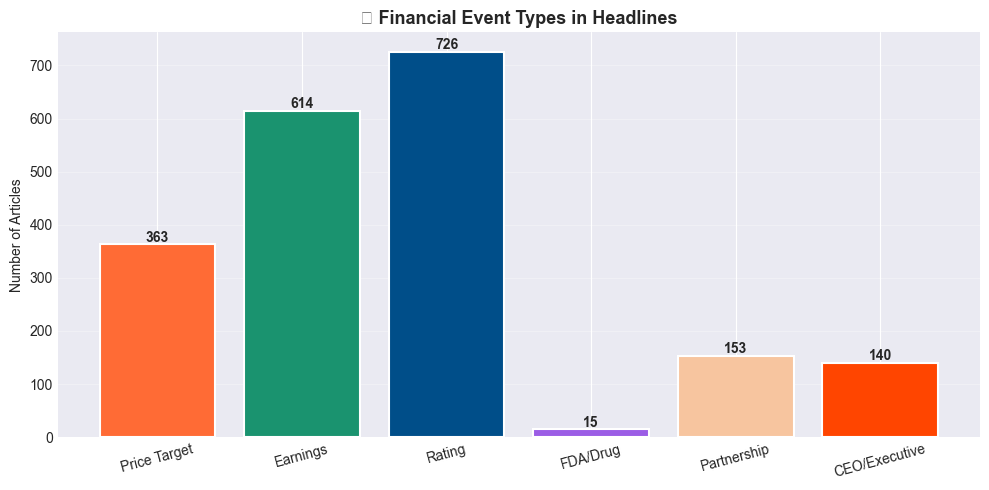

✅ Financial events chart saved!


In [20]:
# Look for specific financial events in headlines
financial_events = {
    "Price Target": ["price target", "target price"],
    "Earnings":     ["earnings", "eps", "profit", "revenue", "quarterly"],
    "Rating":       ["upgrade", "downgrade", "buy", "sell", "neutral", "hold"],
    "FDA/Drug":     ["fda", "drug", "approval", "clinical"],
    "Partnership":  ["partnership", "deal", "agreement", "merger", "acquisition"],
    "CEO/Executive":["ceo", "executive", "president", "appointed", "resign"],
}

print("=== 📰 FINANCIAL EVENT ANALYSIS ===\n")
event_counts = {}
for event, keywords in financial_events.items():
    count = filtered_news["headline"].str.lower().apply(
        lambda x: any(k in x for k in keywords)
    ).sum()
    event_counts[event] = count
    print(f"{event:<20}: {count:>5} articles ({count/len(filtered_news)*100:.1f}%)")

# Plot
plt.figure(figsize=(10, 5))
plt.bar(event_counts.keys(), event_counts.values(),
        color=["#FF6B35", "#1A936F", "#004E89", "#9B5DE5", "#F7C59F", "#FF4500"],
        edgecolor="white", linewidth=1.5)
plt.title("📰 Financial Event Types in Headlines",
          fontweight="bold", fontsize=13)
plt.ylabel("Number of Articles")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
for i, (event, count) in enumerate(event_counts.items()):
    plt.text(i, count + 5, str(count), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/financial_events.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Financial events chart saved!")